# Metodología de preprocesamiento

1. Visualizar al atributo a preprocesar 
2. Inferir la estrategia de preprocesamiento. 
3. Justificar la estrategia de preprocesamiento desde referentes teóricos. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
path_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_semanal_meteo_epi.xlsx"
path_marco = r"C:\Users\marco\Documentos\investigacion\arima\05_preprocesado\1_escalado\2_datos\1_raw\meteo_epi_rezagos.xlsx"
df_meteo_epi_rezagos = pd.read_excel(path_marco)
# hacer que fecha sea el indice y sea de tipo datetime
df_meteo_epi_rezagos['fecha'] = pd.to_datetime(df_meteo_epi_rezagos['fecha']) # convertir en tipo datetime
df_meteo_epi_rezagos.set_index('fecha', inplace=True)  # hacer que fecha sea el indice

df_meteo_epi_rezagos.head()

,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,soi_lag_8,soi_lag_9,soi_lag_10,soi_lag_11,soi_lag_12,sst_lag_8,sst_lag_9,sst_lag_10,sst_lag_11,sst_lag_12
fecha,,,,,,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-10,2021,2,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-17,2021,3,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-24,2021,4,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-31,2021,5,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_meteo_epi_rezagos.columns 

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       ...
       'soi_lag_8', 'soi_lag_9', 'soi_lag_10', 'soi_lag_11', 'soi_lag_12',
       'sst_lag_8', 'sst_lag_9', 'sst_lag_10', 'sst_lag_11', 'sst_lag_12'],
      dtype='str', length=114)

In [4]:
# Lista de columnas que deseas excluir
columnas_a_excluir = ['casos_dengue', 'semana_epi', 'año']

# Comprensión de listas para filtrar las columnas
variables_a_estandarizar = [col for col in df_meteo_epi_rezagos.columns if col not in columnas_a_excluir]

# Prompt  

Ahora, dame el código para estalar las columnas de este dataframe correspondientes a las variables a estandarizar y luego definir el dataframe `df_meteo_epi_rezagos_estandarizado` con las variables entandarizadas e incluir las variables no estandarizadas con StandardScaler de sklearn

In [5]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# 1. Definir el ColumnTransformer
# 'passthrough' indica que las columnas NO incluidas en 'variables_a_estandarizar' se mantendrán sin cambios
preprocesador = ColumnTransformer(
    transformers=[
        ('estandarizar', StandardScaler(), variables_a_estandarizar)
    ],
    remainder='passthrough'
)

# 2. Aplicar la transformación y crear el nuevo DataFrame
# ColumnTransformer devuelve un array de NumPy, por lo que lo convertimos de vuelta a DataFrame
datos_transformados = preprocesador.fit_transform(df_meteo_epi_rezagos)

# 3. Recuperar el orden correcto de los nombres de las columnas
# ColumnTransformer coloca primero las columnas transformadas y luego las del 'remainder'
columnas_transformadas = variables_a_estandarizar + [col for col in df_meteo_epi_rezagos.columns if col not in variables_a_estandarizar]

df_meteo_epi_rezagos_estandarizado = pd.DataFrame(datos_transformados, columns=columnas_transformadas)

In [7]:
df_meteo_epi_rezagos_estandarizado.head()

,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,...,soi_lag_11,soi_lag_12,sst_lag_8,sst_lag_9,sst_lag_10,sst_lag_11,sst_lag_12,año,semana_epi,casos_dengue
0,0.558449,1.011539,-0.710930,-1.562908,-1.177570,-0.869497,-1.424034,-1.083044,-0.784872,0.952168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.0,1.0,0.0
1,0.809785,1.263606,-0.278438,-0.921029,-0.956154,-0.465982,0.273103,-1.670589,-1.581684,0.290635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.0,2.0,0.0
2,1.407759,1.782957,-0.404440,-1.727714,-1.696977,-1.113721,-1.848319,-1.148327,-1.298373,0.841912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.0,3.0,1.0
3,1.182585,1.642976,-0.273330,-1.429906,-1.422558,-0.690470,0.273103,-1.148327,-1.386908,0.070124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.0,4.0,0.0
4,1.321800,1.608995,0.303894,-0.925848,-1.270769,-0.505452,-0.575466,-1.409458,-1.316080,-0.370898,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.0,5.0,0.0


In [6]:
df_meteo_epi_rezagos_estandarizado.to_excel(r"C:\Users\marco\Documentos\investigacion\arima\05_preprocesado\1_escalado\2_datos\2_procesados\meteo_epi_rezagos_estandarizado.xlsx", index = False)

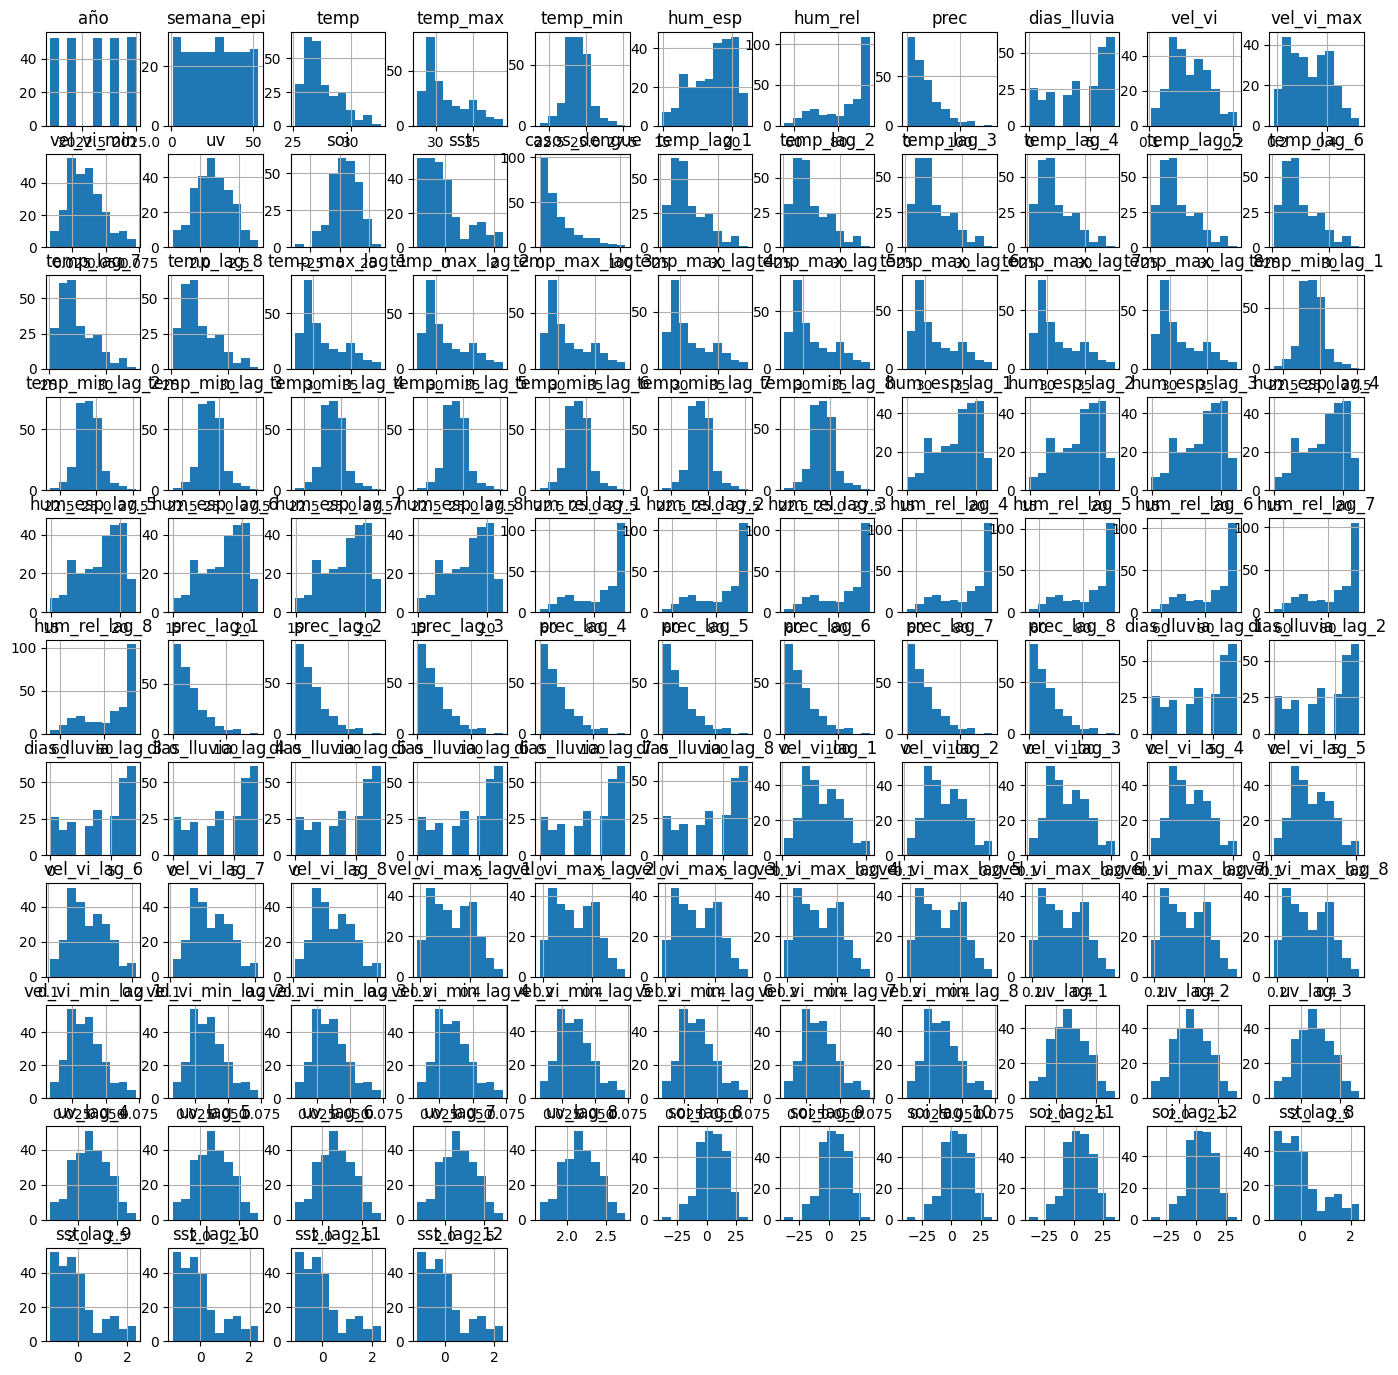

In [8]:
# Histogramas de todas las variables transformadas y estandarizadas sin las columnas de lambda
df_meteo_epi_rezagos.hist(figsize=(17,17))
plt.show() 

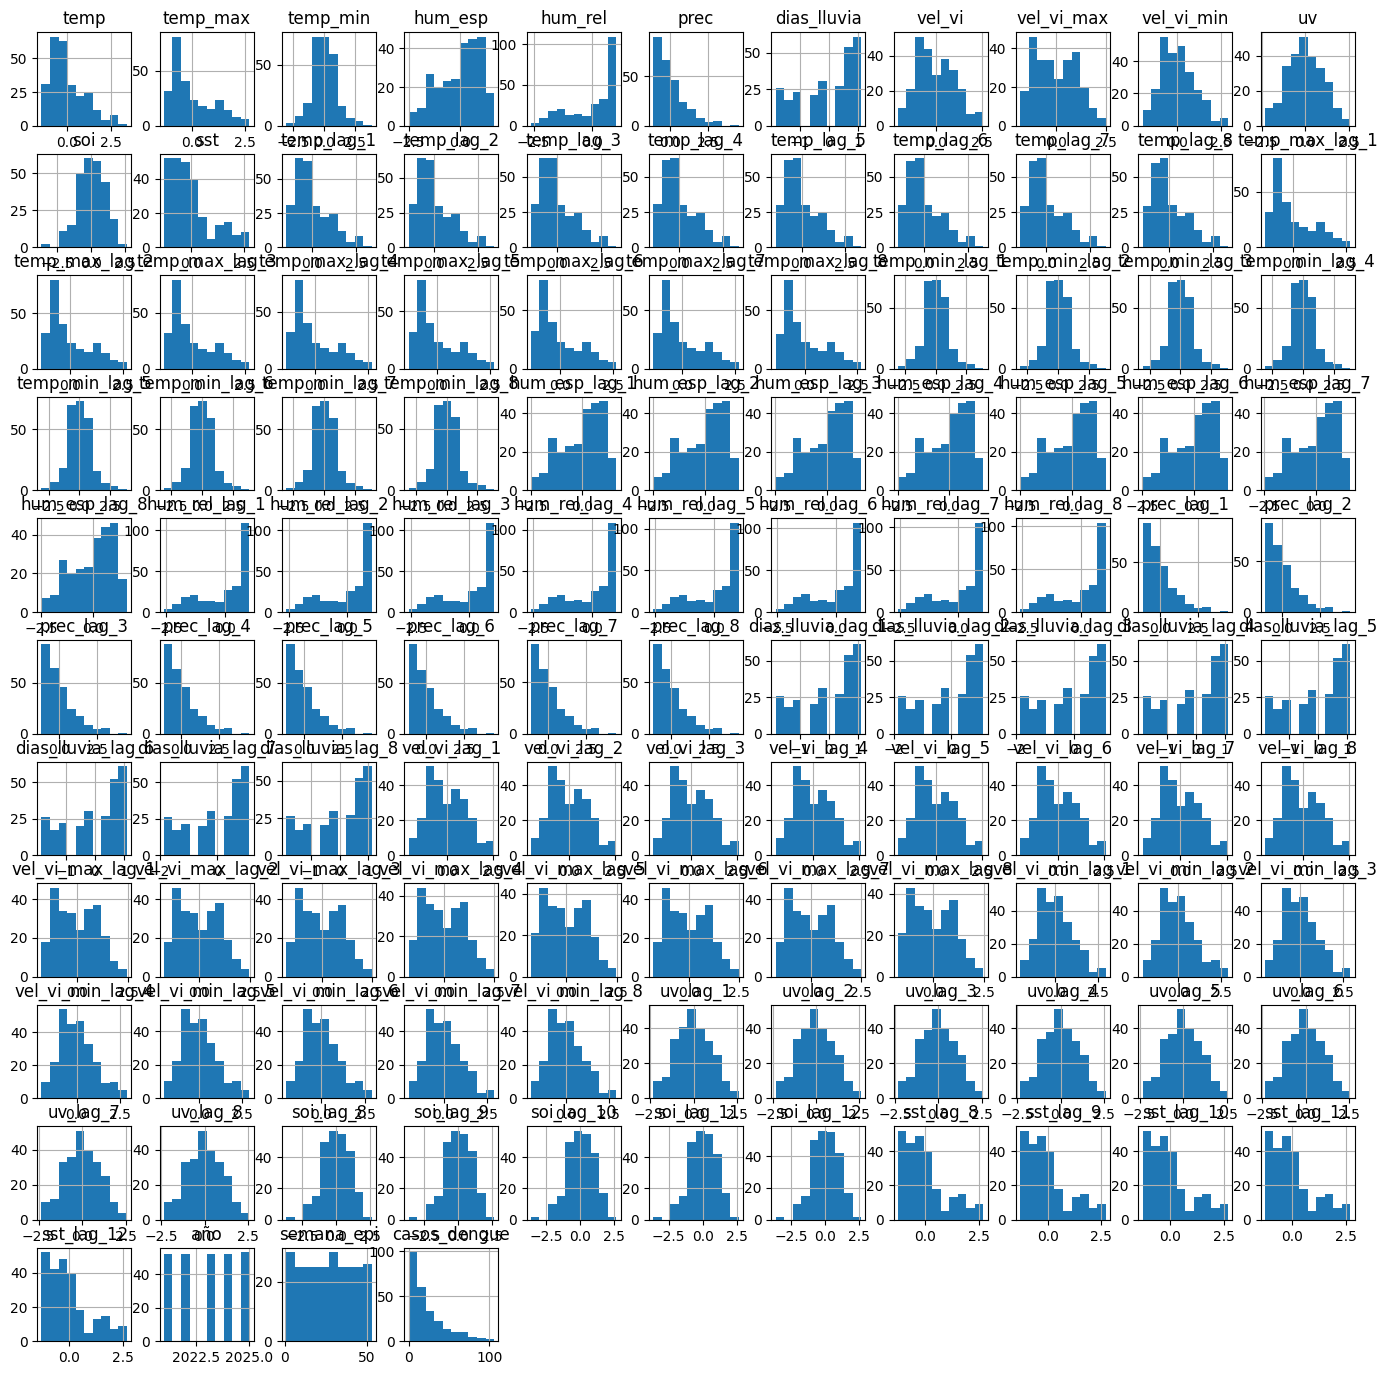

In [9]:
# Histogramas de todas las variables transformadas y estandarizadas sin las columnas de lambda
df_meteo_epi_rezagos_estandarizado.hist(figsize=(17,17))
plt.savefig(f"1.histogramas_procesados_sin_rezagos.png")
plt.show() 